In [5]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import (
    ttest_ind,
    chi2_contingency,
    f_oneway,
    mannwhitneyu
)

import statsmodels.api as sm
from statsmodels.stats.multitest import multipletests

import warnings
warnings.filterwarnings("ignore")

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [7]:
df = pd.read_csv("insurance.csv")

In [6]:
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [8]:
print("Shape of dataset:", df.shape)

Shape of dataset: (1338, 7)


In [9]:
print("Columns:")
print(df.columns.tolist())

Columns:
['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [11]:
df.describe(include="all")

,age,sex,bmi,children,smoker,region,charges
count,1338.000000,1338,1338.000000,1338.000000,1338,1338,1338.000000
unique,NaN,2,NaN,NaN,2,4,NaN
top,NaN,male,NaN,NaN,no,southeast,NaN
freq,NaN,676,NaN,NaN,1064,364,NaN
mean,39.207025,NaN,30.663397,1.094918,NaN,NaN,13270.422265
std,14.049960,NaN,6.098187,1.205493,NaN,NaN,12110.011237
min,18.000000,NaN,15.960000,0.000000,NaN,NaN,1121.873900
25%,27.000000,NaN,26.296250,0.000000,NaN,NaN,4740.287150
50%,39.000000,NaN,30.400000,1.000000,NaN,NaN,9382.033000
75%,51.000000,NaN,34.693750,2.000000,NaN,NaN,16639.912515


In [14]:
missing_values = df.isnull().sum()

print(missing_values)

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


In [15]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_table = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Missing Percentage": missing_percentage
})

missing_table

,Missing Values,Missing Percentage
age,0,0.0
sex,0,0.0
bmi,0,0.0
children,0,0.0
smoker,0,0.0
region,0,0.0
charges,0,0.0


In [16]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 1


In [17]:
df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (1337, 7)


In [18]:
df.dtypes

,0
age,int64
sex,object
bmi,float64
children,int64
smoker,object
region,object
charges,float64


In [19]:
numerical_columns = df.select_dtypes(include=np.number).columns.tolist()
categorical_columns = df.select_dtypes(include="object").columns.tolist()

print("Numerical columns:")
print(numerical_columns)

print("\nCategorical columns:")
print(categorical_columns)

Numerical columns:
['age', 'bmi', 'children', 'charges']

Categorical columns:
['sex', 'smoker', 'region']


In [21]:
df[["age", "bmi", "children", "charges"]].describe()

,age,bmi,children,charges
count,1337.000000,1337.000000,1337.000000,1337.000000
mean,39.222139,30.663452,1.095737,13279.121487
std,14.044333,6.100468,1.205571,12110.359656
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.290000,0.000000,4746.344000
50%,39.000000,30.400000,1.000000,9386.161300
75%,51.000000,34.700000,2.000000,16657.717450
max,64.000000,53.130000,5.000000,63770.428010


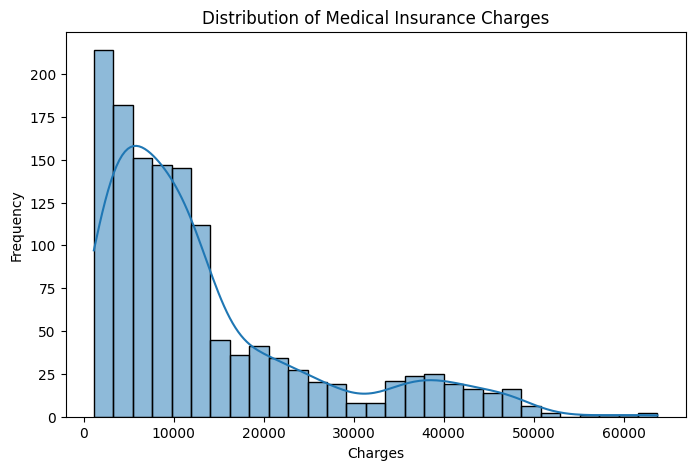

In [22]:
plt.figure(figsize=(8, 5))

sns.histplot(df["charges"], kde=True)

plt.title("Distribution of Medical Insurance Charges")
plt.xlabel("Charges")
plt.ylabel("Frequency")

plt.show()

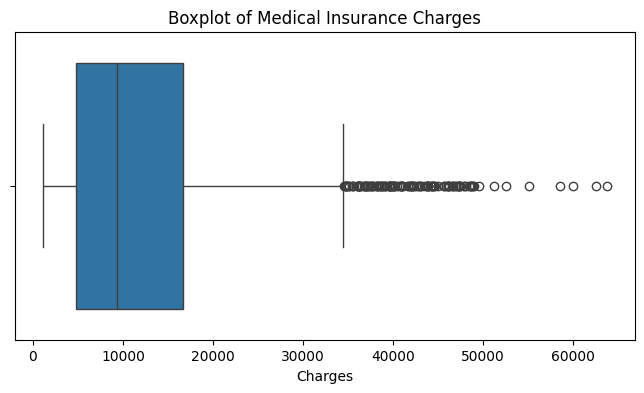

In [23]:
plt.figure(figsize=(8, 4))

sns.boxplot(x=df["charges"])

plt.title("Boxplot of Medical Insurance Charges")
plt.xlabel("Charges")

plt.show()

In [24]:
ALPHA = 0.05

print("Significance level:", ALPHA)

Significance level: 0.05


In [26]:
def choose_test(group_count, variable_type, normal=True):
    """
    Suggest an appropriate statistical test.

    Parameters
    ----------
    group_count : int
        Number of groups being compared.

    variable_type : str
        Type of outcome variable:
        'continuous' or 'categorical'

    normal : bool
        Whether the continuous variable approximately follows
        normality assumptions.

    Returns
    -------
    str
        Recommended statistical test.
    """

    if variable_type == "categorical":
        return "Chi-square test"

    if variable_type == "continuous":

        if group_count == 2:

            if normal:
                return "Independent samples t-test"
            else:
                return "Mann-Whitney U test"

        elif group_count >= 3:

            if normal:
                return "One-way ANOVA"
            else:
                return "Kruskal-Wallis test"

    return "No suitable test found"

In [27]:
print(choose_test(
    group_count=2,
    variable_type="continuous",
    normal=False
))

Mann-Whitney U test


In [28]:
print(choose_test(
    group_count=3,
    variable_type="continuous",
    normal=True
))

One-way ANOVA


In [29]:
df.groupby("smoker")["charges"].agg(
    ["count", "mean", "median", "std"]
)

,count,mean,median,std
smoker,,,,
no,1063,8440.660307,7345.72660,5992.973800
yes,274,32050.231832,34456.34845,11541.547176


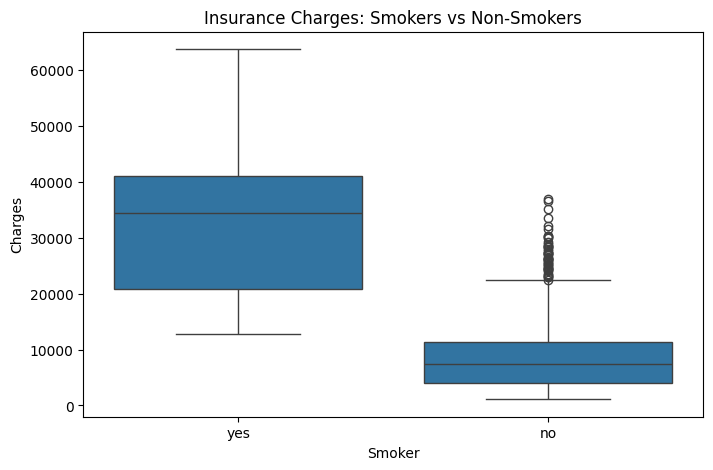

In [30]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x="smoker", y="charges")

plt.title("Insurance Charges: Smokers vs Non-Smokers")
plt.xlabel("Smoker")
plt.ylabel("Charges")

plt.show()

In [31]:
smokers = df[df["smoker"] == "yes"]["charges"]
non_smokers = df[df["smoker"] == "no"]["charges"]

t_stat, p_value = ttest_ind(
    smokers,
    non_smokers,
    equal_var=False
)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: 32.7423097372529
P-value: 6.261720774727631e-103


In [32]:
equal_var=False

In [33]:
if p_value < ALPHA:
    print("Result: Reject the null hypothesis.")
    print("There is statistically significant evidence of a difference in charges.")
else:
    print("Result: Fail to reject the null hypothesis.")
    print("There is not enough evidence to conclude that charges differ.")

Result: Reject the null hypothesis.
There is statistically significant evidence of a difference in charges.


In [34]:
def cohens_d(group1, group2):
    """
    Calculate Cohen's d for two independent groups.
    """

    n1 = len(group1)
    n2 = len(group2)

    mean1 = np.mean(group1)
    mean2 = np.mean(group2)

    var1 = np.var(group1, ddof=1)
    var2 = np.var(group2, ddof=1)

    pooled_std = np.sqrt(
        ((n1 - 1) * var1 + (n2 - 1) * var2)
        / (n1 + n2 - 2)
    )

    return (mean1 - mean2) / pooled_std

In [35]:
d = cohens_d(smokers, non_smokers)

print("Cohen's d:", d)

Cohen's d: 3.160290276658123


In [36]:
u_stat, p_value_mw = mannwhitneyu(
    smokers,
    non_smokers,
    alternative="two-sided"
)

print("Mann-Whitney U statistic:", u_stat)
print("P-value:", p_value_mw)

Mann-Whitney U statistic: 283859.0
P-value: 5.74701188239214e-130


In [37]:
if p_value_mw < ALPHA:
    print("Reject H0: the distributions differ significantly.")
else:
    print("Fail to reject H0.")

Reject H0: the distributions differ significantly.


In [38]:
contingency_table = pd.crosstab(
    df["sex"],
    df["smoker"]
)

contingency_table

smoker,no,yes
sex,,
female,547,115
male,516,159


In [39]:
chi2, p_value_chi, dof, expected = chi2_contingency(
    contingency_table
)

print("Chi-square statistic:", chi2)
print("Degrees of freedom:", dof)
print("P-value:", p_value_chi)

Chi-square statistic: 7.469139330086637
Degrees of freedom: 1
P-value: 0.0062765550120107375


In [42]:
if p_value_chi < ALPHA:
    print("Reject H0.")
    print("There is a statistically significant association between sex and smoking.")
else:
    print("Fail to reject H0.")
    print("There is insufficient evidence of an association.")

Reject H0.
There is a statistically significant association between sex and smoking.


In [44]:
df.groupby("region")["charges"].agg(
    ["count", "mean", "median", "std"]
)

,count,mean,median,std
region,,,,
northeast,324,13406.384516,10057.652025,11255.803066
northwest,324,12450.840844,8976.977250,11073.125699
southeast,364,14735.411438,9294.131950,13971.098589
southwest,325,12346.937377,8798.593000,11557.179101


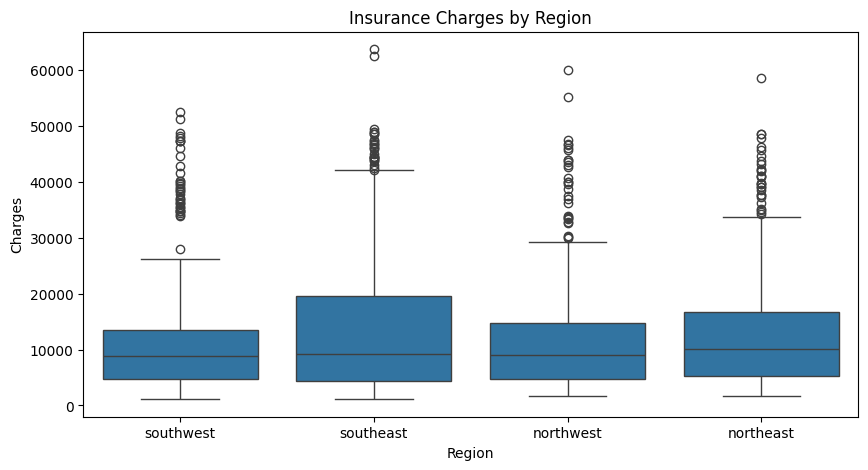

In [45]:
plt.figure(figsize=(10, 5))

sns.boxplot(
    data=df,
    x="region",
    y="charges"
)

plt.title("Insurance Charges by Region")
plt.xlabel("Region")
plt.ylabel("Charges")

plt.show()

In [47]:
region_groups = [
    group["charges"].values
    for _, group in df.groupby("region")
]

In [48]:
f_stat, p_value_anova = f_oneway(*region_groups)

print("F-statistic:", f_stat)
print("P-value:", p_value_anova)

F-statistic: 2.926139903662777
P-value: 0.03276288025444947


In [49]:
if p_value_anova < ALPHA:
    print("Reject H0.")
    print("At least one region has a statistically different mean charge.")
else:
    print("Fail to reject H0.")
    print("There is insufficient evidence that mean charges differ by region.")

Reject H0.
At least one region has a statistically different mean charge.


In [50]:
def mean_difference_ci(group1, group2, confidence=0.95):
    """
    Calculate confidence interval for difference
    between two independent means using Welch's method.
    """

    x1 = np.asarray(group1)
    x2 = np.asarray(group2)

    n1 = len(x1)
    n2 = len(x2)

    mean_diff = np.mean(x1) - np.mean(x2)

    var1 = np.var(x1, ddof=1)
    var2 = np.var(x2, ddof=1)

    standard_error = np.sqrt(
        var1 / n1 + var2 / n2
    )

    degrees_freedom = (
        (var1/n1 + var2/n2) ** 2 /
        (
            (var1/n1)**2/(n1-1) +
            (var2/n2)**2/(n2-1)
        )
    )

    alpha = 1 - confidence

    critical_value = stats.t.ppf(
        1 - alpha/2,
        degrees_freedom
    )

    margin_error = critical_value * standard_error

    lower = mean_diff - margin_error
    upper = mean_diff + margin_error

    return mean_diff, lower, upper

In [51]:
difference, lower, upper = mean_difference_ci(
    smokers,
    non_smokers
)

print("Mean difference:", difference)
print("95% CI lower:", lower)
print("95% CI upper:", upper)

Mean difference: 23609.571525023905
95% CI lower: 22190.79008570521
95% CI upper: 25028.3529643426


In [52]:
from itertools import combinations

regions = df["region"].unique()

results = []

for region1, region2 in combinations(regions, 2):

    group1 = df[df["region"] == region1]["charges"]
    group2 = df[df["region"] == region2]["charges"]

    stat, p = ttest_ind(
        group1,
        group2,
        equal_var=False
    )

    results.append({
        "Group 1": region1,
        "Group 2": region2,
        "Statistic": stat,
        "Raw P-value": p
    })

pairwise_results = pd.DataFrame(results)

pairwise_results

,Group 1,Group 2,Statistic,Raw P-value
0,southwest,southeast,-2.454116,0.014372
1,southwest,northwest,-0.116944,0.906941
2,southwest,northeast,-1.183014,0.237238
3,southeast,northwest,2.388747,0.017179
4,southeast,northeast,1.380165,0.167990
5,northwest,northeast,-1.089320,0.276419


In [53]:
reject, corrected_p, _, _ = multipletests(
    pairwise_results["Raw P-value"],
    alpha=ALPHA,
    method="bonferroni"
)

pairwise_results["Corrected P-value"] = corrected_p
pairwise_results["Significant"] = reject

pairwise_results

,Group 1,Group 2,Statistic,Raw P-value,Corrected P-value,Significant
0,southwest,southeast,-2.454116,0.014372,0.086230,False
1,southwest,northwest,-0.116944,0.906941,1.000000,False
2,southwest,northeast,-1.183014,0.237238,1.000000,False
3,southeast,northwest,2.388747,0.017179,0.103073,False
4,southeast,northeast,1.380165,0.167990,1.000000,False
5,northwest,northeast,-1.089320,0.276419,1.000000,False


In [54]:
def interpret_p_value(p_value, alpha=0.05):
    """
    Interpret a p-value at a given significance level.
    """

    if p_value < alpha:
        return "Reject H0: statistically significant."
    else:
        return "Fail to reject H0: not statistically significant."

In [56]:
print(interpret_p_value(0.03))
print(interpret_p_value(0.20))

Reject H0: statistically significant.
Fail to reject H0: not statistically significant.


In [57]:
results_summary = pd.DataFrame({
    "Test": [
        "Welch's t-test",
        "Mann-Whitney U",
        "Chi-square",
        "One-way ANOVA"
    ],
    "P-value": [
        p_value,
        p_value_mw,
        p_value_chi,
        p_value_anova
    ]
})

results_summary["Significant"] = (
    results_summary["P-value"] < ALPHA
)

results_summary

,Test,P-value,Significant
0,Welch's t-test,6.261721e-103,True
1,Mann-Whitney U,5.747012e-130,True
2,Chi-square,6.276555e-03,True
3,One-way ANOVA,3.276288e-02,True
